# The code behind it: simulate a random variable

*Part 1 · Lesson 7 · the code behind it  ·  data: dice simulation · US Births 2014 (same as Lesson 7)*

*↩ A companion to [Lesson 7: Random variables, expectation & variance](07-random-variables.ipynb).*

**↩ Back:** [Lesson 7: Random variables, expectation & variance](07-random-variables.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset →](07-random-variables~another-dataset.ipynb)

**In Lesson 7 you met random variables on paper** — a fair die's expected value is *exactly* 3.5, its
variance is $35/12$, and the law of large numbers *promises* the average will settle there. This companion
**opens the hood**: instead of trusting the formulas, you'll **simulate** them. You'll roll a die a hundred
thousand times in one line, build its probability distribution by *counting* what came up, and compute
$E[X]$ and $\operatorname{Var}[X]$ straight from arrays — then watch them land on the textbook numbers.

Same die, same US births, same final answers — but the focus shifts from *what expectation means* to **how
you make randomness happen (reproducibly) in Python**. We'll go in the order a programmer actually works:

1. **The goal** — what we're building.
2. **The data in code** — a seeded random generator, and the simulated rolls it produces.
3. **Build it step by step** — turn rolls into an empirical PMF, then into $E$, $\operatorname{Var}$, $\operatorname{SD}$ — each checked against theory and against numpy with `np.isclose`.
4. **The idiom** — *vectorized* simulation vs. a Python `for`-loop one roll at a time, and `np.cumsum` for the running mean.
5. **Refactor into functions** — your own `expectation()` and `variance()`, reused on one die *and* the sum of two.
6. **Now you code** — predict-then-run exercises.
7. **What you learned** — the coding *and* the statistics.

You don't need Lesson 7 fresh in mind, but it helps. Run each grey cell with **Shift + Enter**, top to bottom.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

## 1) The goal

By the end of this notebook you'll have *simulated* a random variable rather than looked it up: rolled a
fair die 100,000 times in a single line, built its probability distribution by counting, and written two
short functions — `expectation()` and `variance()` — that take the values and their probabilities and hand
back $E[X]$ and $\operatorname{Var}[X]$. You'll check every from-scratch number against the textbook value
*and* against numpy's own `.mean()` / `.var()`, and watch the law of large numbers happen as a chart.

The tools we'll use, and what each is for:

| Tool | What it is | What we use it for |
|---|---|---|
| **NumPy** | fast math on whole arrays at once | the random generator, the rolls, the PMF arithmetic |
| **`np.random.default_rng`** | a seedable random-number generator | rolling dice *reproducibly* |
| **matplotlib** | plotting | the PMF bar charts and the law-of-large-numbers curve |

The one new idea is the **generator**. `rng = np.random.default_rng(0)` makes a stream of randomness with a
fixed **seed** (`0`), so the "random" rolls come out *the same every time the notebook runs* — essential for
a lesson whose numbers must be reproducible. Change the seed and you get a different (but equally valid) run.

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sl.use_course_style()

rng = np.random.default_rng(0)   # seeded -> the same rolls every run; change 0 to reshuffle
print('Ready. NumPy version:', np.__version__)

Ready. NumPy version: 2.4.6


## 2) The data in code

There's no CSV to load yet — our "data" is *manufactured* by the generator. One line rolls a fair die `N`
times: `rng.integers(1, 7, size=N)` draws whole numbers from 1 up to **but not including** 7 (so 1–6), each
equally likely. The result is a plain NumPy array of `N` rolls.

Before any statistics, a programmer *interrogates the object*: what type is it, how big, what values does it
hold? Same habits as with a real table — `type(...)`, `.shape`, a peek at the first few, and the set of
distinct values.

In [2]:
N = 100_000                              # a large number of rolls
rolls = rng.integers(1, 7, size=N)       # whole numbers 1..6, each equally likely

print('type        :', type(rolls).__name__)
print('shape       :', rolls.shape, ' (one row of', N, 'rolls)')
print('dtype       :', rolls.dtype)
print('first 15    :', rolls[:15])
print('distinct vals:', np.unique(rolls))   # should be exactly 1..6
print(f'\nrolls.mean() = {rolls.mean():.4f}   (we expect something near 3.5)')

type        : ndarray
shape       : (100000,)  (one row of 100000 rolls)
dtype       : int64
first 15    : [6 4 4 2 2 1 1 1 2 5 4 6 4 4 6]
distinct vals: [1 2 3 4 5 6]

rolls.mean() = 3.4980   (we expect something near 3.5)


## 3) Build it step by step

Now the heart of it. We'll turn the raw rolls into a **probability distribution** (a PMF) by counting, then
feed that PMF into the definitions of $E[X]$ and $\operatorname{Var}[X]$. At every step we check our
from-scratch number against two things: the **theory** (a fair die's known answers) and **numpy's own**
`.mean()` / `.var()`. Once they match to the decimal, the formula is no longer a mystery box.

### The empirical PMF — count, then divide

We don't *assume* each face is $1/6$; we **measure** it. `np.unique(rolls, return_counts=True)` returns
each distinct value and how many times it appeared; dividing the counts by `N` turns them into
probabilities. This is the empirical (data-driven) PMF:

$$\hat{P}(X=x) = \frac{\text{number of rolls equal to } x}{N}.$$

In [3]:
values, counts = np.unique(rolls, return_counts=True)   # the faces, and how often each came up
probs = counts / N                                       # empirical P(X = x)

print('value   count    P(X=x)    true 1/6')
for v, c, p in zip(values, counts, probs):
    print(f'  {v}    {c:6d}    {p:.4f}    {1/6:.4f}')
print(f'\nProbabilities sum to {probs.sum():.4f}  (must be 1).')

true_p = np.full(6, 1/6)
print('close to a flat 1/6 each?', np.allclose(probs, true_p, atol=0.01))

value   count    P(X=x)    true 1/6
  1     16716    0.1672    0.1667
  2     16529    0.1653    0.1667
  3     16797    0.1680    0.1667
  4     16693    0.1669    0.1667
  5     16729    0.1673    0.1667
  6     16536    0.1654    0.1667

Probabilities sum to 1.0000  (must be 1).
close to a flat 1/6 each? True


### Expected value E[X], from its definition

The **expected value** is the probability-weighted average of the values:

$$E[X] = \sum_x x\,P(x).$$

In vectorized code that is literally `np.sum(values * probs)` — multiply the two arrays element-by-element,
then add. We compare it three ways: against the **theoretical** fair-die mean **3.5**, and against numpy's
plain `rolls.mean()` on the raw rolls.

In [4]:
E = np.sum(values * probs)        # sum of x * P(x), straight from the definition

E_theory = 3.5                    # (1+2+3+4+5+6)/6 for a fair die
E_numpy  = rolls.mean()           # numpy's average of the raw rolls

print(f'E[X] from the PMF : {E:.4f}')
print(f'theoretical mean  : {E_theory:.4f}')
print(f'rolls.mean()      : {E_numpy:.4f}')
print('match (PMF vs numpy)? ', np.isclose(E, E_numpy))
print('close to theory 3.5?  ', np.isclose(E, E_theory, atol=0.02))

E[X] from the PMF : 3.4980
theoretical mean  : 3.5000
rolls.mean()      : 3.4980
match (PMF vs numpy)?  True
close to theory 3.5?   True


### Variance and standard deviation, from their definitions

The **variance** is the probability-weighted average *squared* distance from the mean; the **SD** is its
square root:

$$\operatorname{Var}[X] = \sum_x (x - E[X])^2\,P(x), \qquad \operatorname{SD}[X] = \sqrt{\operatorname{Var}[X]}.$$

Watch the vectorization: `values - E` subtracts the mean from **every** value at once, `** 2` squares each,
`* probs` weights them, `np.sum(...)` adds. No loop. The theoretical fair-die variance is $35/12 \approx
2.9167$.

One deliberate `ddof` choice: a PMF-based variance divides by the full weight (it's a **population**
variance), so we compare it to `rolls.var(ddof=0)` — numpy's *population* variance, dividing by $N$. (We'd
pass `ddof=1` only when we want the *sample* variance that divides by $N-1$; that isn't what the PMF
formula computes.)

In [5]:
Var = np.sum((values - E)**2 * probs)    # sum of (x - E)^2 * P(x)
SD  = np.sqrt(Var)

Var_theory = 35/12                        # exact fair-die variance
Var_numpy  = rolls.var(ddof=0)            # population variance of the raw rolls (divide by N)

print(f'Var[X] from the PMF : {Var:.4f}')
print(f'theoretical 35/12   : {Var_theory:.4f}')
print(f'rolls.var(ddof=0)   : {Var_numpy:.4f}')
print('match (PMF vs numpy)? ', np.isclose(Var, Var_numpy))
print('close to theory?      ', np.isclose(Var, Var_theory, atol=0.02))
print(f'\nSD[X] from the PMF : {SD:.4f}   (theoretical sqrt(35/12) = {np.sqrt(Var_theory):.4f})')

Var[X] from the PMF : 2.9103
theoretical 35/12   : 2.9167
rolls.var(ddof=0)   : 2.9103
match (PMF vs numpy)?  True
close to theory?       True

SD[X] from the PMF : 1.7060   (theoretical sqrt(35/12) = 1.7078)


### The law of large numbers — watch the average converge

We *defined* $E[X]$ as the long-run average. The **law of large numbers** makes that precise: as rolls pile
up, the **running average** settles toward 3.5. The trick is `np.cumsum(rolls)`, which gives the running
*total* after each roll; dividing by `np.arange(1, N+1)` (1, 2, 3, ... rolls so far) turns it into the
running *mean* — the whole curve in two vectorized lines, no loop.

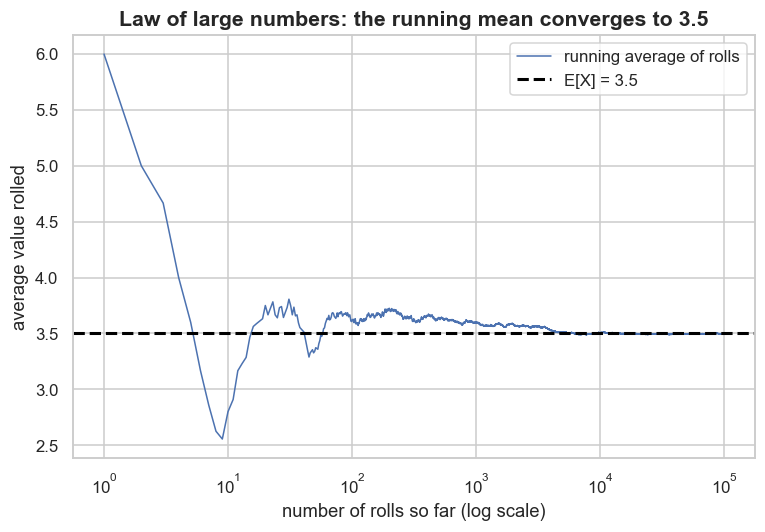

Average of first 10 rolls   : 2.800
Average of all 100,000 rolls : 3.498   (target 3.5)


In [6]:
running_avg = np.cumsum(rolls) / np.arange(1, N + 1)   # average of the first k rolls, for every k

fig, ax = plt.subplots()
ax.plot(np.arange(1, N + 1), running_avg, color='#4c72b0', lw=1.0,
        label='running average of rolls')
ax.axhline(E_theory, color='black', lw=2, ls='--', label='E[X] = 3.5')
ax.set_xscale('log')                                   # log x spreads out the early, jumpy part
ax.set_xlabel('number of rolls so far (log scale)'); ax.set_ylabel('average value rolled')
ax.set_title('Law of large numbers: the running mean converges to 3.5')
ax.legend(); plt.show()

print(f'Average of first 10 rolls   : {running_avg[9]:.3f}')
print(f'Average of all {N:,} rolls : {running_avg[-1]:.3f}   (target 3.5)')

## 4) The idiom — vectorized simulation vs. a loop

You *could* roll the die one face at a time in a Python `for` loop. It gives the same distribution but is
slower and noisier to read. The idiom is to ask the generator for the whole batch at once with
`size=N`. Let's build both and time them so the difference is visible.

In [7]:
import time

# The loop way (how you might first think of it): roll one die at a time.
rng_loop = np.random.default_rng(0)
t0 = time.perf_counter()
loop_rolls = np.empty(N, dtype=int)
for i in range(N):
    loop_rolls[i] = rng_loop.integers(1, 7)
t_loop = time.perf_counter() - t0

# The vectorized way (what the generator is for): the whole batch in one call.
rng_vec = np.random.default_rng(0)
t0 = time.perf_counter()
vec_rolls = rng_vec.integers(1, 7, size=N)
t_vec = time.perf_counter() - t0

print(f'loop      mean of {N:,} rolls: {loop_rolls.mean():.4f}   in {t_loop*1000:7.1f} ms')
print(f'vectorized mean of {N:,} rolls: {vec_rolls.mean():.4f}   in {t_vec*1000:7.1f} ms')
print(f'\nSame kind of answer (both near 3.5), but vectorized is ~{t_loop/max(t_vec,1e-9):.0f}x faster')
print('and it is one short line. On big simulations this is the difference between seconds and minutes.')

loop      mean of 100,000 rolls: 3.4980   in   111.1 ms
vectorized mean of 100,000 rolls: 3.4980   in     0.3 ms

Same kind of answer (both near 3.5), but vectorized is ~358x faster
and it is one short line. On big simulations this is the difference between seconds and minutes.


## 5) Refactor into reusable functions

You've now written "weighted sum of values" and "weighted sum of squared deviations" by hand. The
programmer's reflex is to **wrap repeated work in a function**: name it, give it inputs, `return` the
result. Then $E[X]$ and $\operatorname{Var}[X]$ are one call each, reusable on *any* distribution — a single
die, the sum of two dice, a real dataset.

In [8]:
def expectation(values, probs):
    '''E[X] = sum of value * probability, straight from the definition.'''
    values = np.asarray(values, dtype=float)
    probs  = np.asarray(probs, dtype=float)
    return np.sum(values * probs)

def variance(values, probs):
    '''Var[X] = sum of (value - E[X])^2 * probability (the population variance).'''
    values = np.asarray(values, dtype=float)
    probs  = np.asarray(probs, dtype=float)
    mu = expectation(values, probs)
    return np.sum((values - mu)**2 * probs)

# Reuse them on the single die — must reproduce Section 3's numbers exactly.
E_fn   = expectation(values, probs)
Var_fn = variance(values, probs)
print(f'expectation(die) = {E_fn:.4f}   variance(die) = {Var_fn:.4f}')
print('match Section 3?', np.isclose(E_fn, E), np.isclose(Var_fn, Var))

expectation(die) = 3.4980   variance(die) = 2.9103
match Section 3? True True


### A derived random variable: the sum of two dice

A function earns its keep when you reuse it on something new. Let $S = X_1 + X_2$, the **sum of two fair
dice** — a fresh random variable with a famous *triangular* distribution peaking at 7. We simulate it
(roll two batches, add them), build its empirical PMF by counting, and feed that PMF to the *same* two
functions. Theory says $E[S] = 7$ (two dice, $2 \times 3.5$) and $\operatorname{Var}[S] = 35/6 \approx
5.8333$ (variances of independent rolls add).

E[S]   from the PMF : 7.0022   (theoretical 7)
Var[S] from the PMF : 5.8360   (theoretical 35/6 = 5.8333)
E[S] vs two_dice.mean()?  True
Var[S] vs two_dice.var(ddof=0)? True
close to theory (7 and 5.833)?  True True


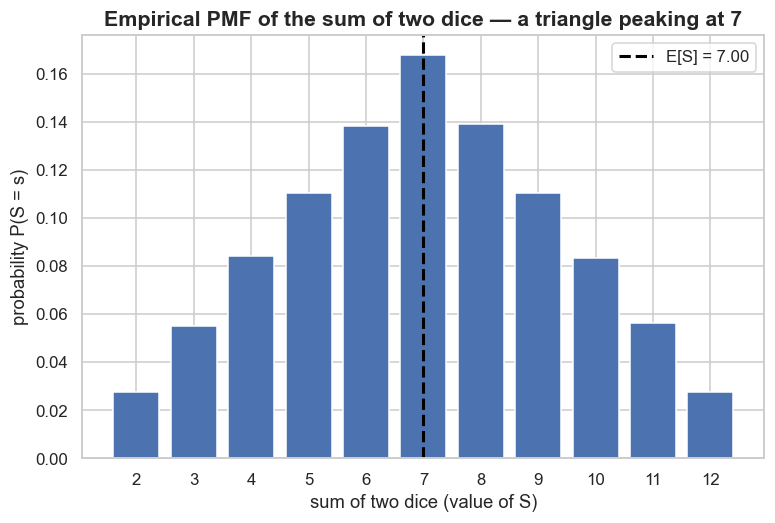

In [9]:
die1 = rng.integers(1, 7, size=N)
die2 = rng.integers(1, 7, size=N)
two_dice = die1 + die2                                   # S = X1 + X2, values 2..12

s_values, s_counts = np.unique(two_dice, return_counts=True)
s_probs = s_counts / N

E_two   = expectation(s_values, s_probs)
Var_two = variance(s_values, s_probs)

print(f'E[S]   from the PMF : {E_two:.4f}   (theoretical 7)')
print(f'Var[S] from the PMF : {Var_two:.4f}   (theoretical 35/6 = {35/6:.4f})')
print('E[S] vs two_dice.mean()? ', np.isclose(E_two, two_dice.mean()))
print('Var[S] vs two_dice.var(ddof=0)?', np.isclose(Var_two, two_dice.var(ddof=0)))
print('close to theory (7 and 5.833)? ',
      np.isclose(E_two, 7, atol=0.05), np.isclose(Var_two, 35/6, atol=0.1))

fig, ax = plt.subplots()
ax.bar(s_values, s_probs, color='#4c72b0', edgecolor='white')
ax.axvline(E_two, color='black', lw=2, ls='--', label=f'E[S] = {E_two:.2f}')
ax.set_xlabel('sum of two dice (value of S)'); ax.set_ylabel('probability P(S = s)')
ax.set_title('Empirical PMF of the sum of two dice — a triangle peaking at 7')
ax.set_xticks(s_values); ax.legend(); plt.show()

### The same functions on REAL data — prenatal visits

The functions never asked the distribution to be a die. Here's the core lesson's **real** random variable:
$X$ = the number of prenatal `visits` for a randomly chosen US birth in 2014. We build its empirical PMF by
counting (dropping the missing values first), then hand it to the *exact same* `expectation()` and
`variance()`. The PMF-based answers must equal the plain data mean and the population variance
`visits.var(ddof=0)`.

In [10]:
births = sl.load_csv('births14.csv', url='https://www.openintro.org/data/csv/births14.csv')
visits = births['visits'].dropna()
n = len(visits)

k_vals, k_counts = np.unique(visits.to_numpy(), return_counts=True)
k_probs = k_counts / n                                   # empirical P(X = k)

E_visits   = expectation(k_vals, k_probs)
Var_visits = variance(k_vals, k_probs)

print(f'births kept (visits recorded): {n}')
print(f'E[X]   from the PMF = {E_visits:.4f}   data mean = {visits.mean():.4f}')
print(f'Var[X] from the PMF = {Var_visits:.4f}   visits.var(ddof=0) = {visits.var(ddof=0):.4f}')
print('match (PMF vs numpy)?', np.isclose(E_visits, visits.mean()),
      np.isclose(Var_visits, visits.var(ddof=0)))
print(f'\nA typical 2014 birth had about {E_visits:.0f} prenatal visits, '
      f'give or take ~{np.sqrt(Var_visits):.0f} (SD).')

births kept (visits recorded): 944
E[X]   from the PMF = 11.3517   data mean = 11.3517
Var[X] from the PMF = 16.8594   visits.var(ddof=0) = 16.8594
match (PMF vs numpy)? True True

A typical 2014 birth had about 11 prenatal visits, give or take ~4 (SD).


## 6) Now you code

Write the code yourself. Add a new cell (the **+** button in the toolbar) and try each — predict the answer
before you run it.

1. **Standard deviation as a function.** Add `sd(values, probs)` that returns `np.sqrt(variance(values, probs))`.
   Call it on the single die — does it match the `SD` printed in Section 3 (about 1.71)?

2. **A loaded die.** Keep the faces `np.array([1,2,3,4,5,6])` but set
   `loaded = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.5])` (a 6 is much more likely). Confirm `loaded.sum()` is
   1, then compute `expectation(values, loaded)` and `variance(values, loaded)`. Predict first: does loading
   the 6 pull $E[X]$ **above** 3.5? Is the variance bigger or smaller than the fair die's 2.92?

3. **A bigger seed sweep.** Re-run the die simulation in Section 2 with `N = 1000` instead of `100_000`
   (and the same `rng = np.random.default_rng(0)`). Is the empirical `E[X]` still close to 3.5? How far does
   the running-average curve wander now versus with 100,000 rolls — what does that say about how *fast* the
   law of large numbers works?

4. **The product of two dice.** You built the *sum* of two dice. Now make `product = die1 * die2` (values
   1–36), build its empirical PMF with `np.unique(..., return_counts=True)`, and use your functions to get
   $E$ and $\operatorname{Var}$. Predict: should $E[\text{product}]$ equal $3.5 \times 3.5 = 12.25$?
   (It does, because the two dice are independent — a fact worth checking by simulation.)

## What you learned

**Coding**
- `rng = np.random.default_rng(0)` makes a **seeded** generator — reproducible randomness, essential when a
  notebook must give the same numbers every run. `rng.integers(1, 7, size=N)` rolls a whole batch at once.
- **Vectorized simulation** (ask for `size=N` in one call) beats a Python `for`-loop rolling one die at a
  time — same distribution, far faster, one line.
- Build an **empirical PMF** by counting: `values, counts = np.unique(rolls, return_counts=True)`, then
  `probs = counts / N`.
- `np.cumsum(rolls) / np.arange(1, N+1)` is the running-average idiom behind the law-of-large-numbers chart.
- **Refactor repeated work into functions** with clear inputs and a `return`, then reuse them on a single
  die, the sum of two dice, and real data alike.

**Statistics (now demystified)**
- $E[X]=\sum_x x\,P(x)$ and $\operatorname{Var}[X]=\sum_x (x-E[X])^2P(x)$ are each a short weighted sum; you
  reproduced the theoretical die values (mean **3.5**, variance **35/12 ≈ 2.9167**) by *counting* simulated
  rolls, and matched numpy's `.mean()` / `.var(ddof=0)` to the decimal.
- A PMF-based variance is the **population** variance (`ddof=0`, divide by $N$) — that's why we compared
  against `rolls.var(ddof=0)`, not the sample `ddof=1`.
- The **law of large numbers** is something you watched happen: the running mean of 100,000 rolls glided to
  3.5, and the same functions gave $E \approx 7$ / $\operatorname{Var} \approx 5.833$ for the sum of two
  dice and the right answers for real prenatal-visit data.

**Back to the core lesson** ([Lesson 7: Random variables, expectation & variance](07-random-variables.ipynb))
for the *meaning* of these numbers, or read on through the course.

---

**↩ Back to the lesson:** [Lesson 7: Random variables, expectation & variance](07-random-variables.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset](07-random-variables~another-dataset.ipynb)